In [1]:
from core.em_project import EMProject
import matplotlib.pyplot as plt
%matplotlib widget

# 1. Start project
project_name = 'multi_tesla'
base_dir = r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations"
proj = EMProject(name=project_name, base_dir=base_dir)

# # 2. Create assembly
# assembly = proj.create_assembly(main_axis='Z')
#
# # 3. Create importers for your files
# # (The code automatically loads the CAD data)
# cav1 = proj.create_importer("./tesla1cell.iges", unit='mm')
# cav2 = proj.create_importer("./tesla1cell.iges", unit='mm')
#
# # 4. Add them to the assembly
# # Assembly will automatically align them based on their bounding boxes
# assembly.add("cavity1", cav1)
# assembly.add("cavity2", cav2, after="cavity1")
#
# # 5. Build and mesh the whole assembly
# assembly.build()
# assembly.generate_mesh(maxh=0.02)
# assembly.show('mesh')
proj.geo.show('mesh')

Project 'multi_tesla' exists. Loading automatically...
Port naming complete:
  Total ports: 3
  External ports: 2
  Interface ports: 1
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [2]:
fom_config = {
    'nportmodes': 3,
    'order': 3,
    'nsamples': 30,
    'fmin': 1e-3,
    'fmax': 5,
    'solver_type': 'direct',
    # 'iterative_opts': {
    #     'precond': 'bddc',
    #     'maxsteps': 500,
    # },
    # 'rerun': True
}
fom_result = proj.fds.solve(config=fom_config)

INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Compound structure
INFO:: Domains (2): ['cavity1', 'cavity2']
INFO:: Total Ports (3): ['port1', 'port2', 'port3']
INFO:: External Ports (2): ['port1', 'port3']
INFO:: Internal Ports (1): ['port2']
INFO:: 
Domain-Port Mapping:
  cavity1: ['port1 (external, input)', 'port2 (internal)']
  cavity2: ['port2 (internal)', 'port3 (external, output)']

Assembling Matrices...
Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 3
	------------------------------------------------------------
	  port1: circular (fit error: 0.0000)
	    R=0.035002
	  port2: circular (fit error: 0.0000)
	    R=0.035002
	  port3: circular (fit error: 0.0000)
	    R=0.035002
	  Precomputing boundary mass matrices (once per port)...
	    Done for 3 port(s)
here is the order of the ports ['port1', 'port2', 'port3']
USIN

Loaded CST S-parameters from: tesla1cell_double
  Frequency range: 0.0010 - 5.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


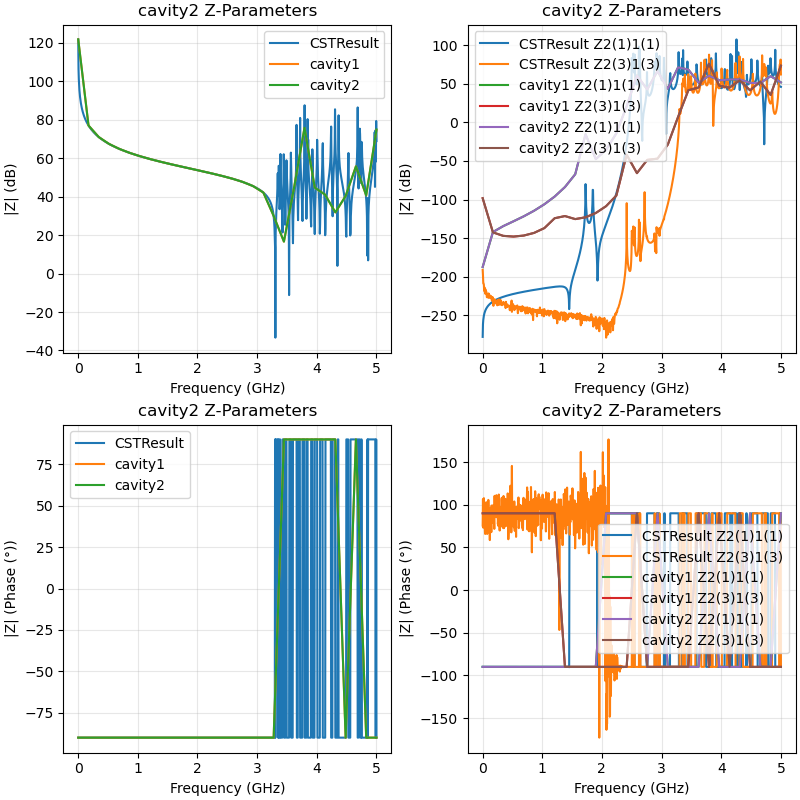

In [3]:
from analytical.cst_result import CSTResult
%matplotlib widget

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\tesla1cell_double')
# plot comparison
which = [['1(3)1(3)'], ['2(1)1(1)', '2(3)1(3)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_z(wh, ax=axs[idx+1])
    proj.fds.foms.plot_z(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_z(wh, plot_type='phase', ax=axs[idx+3])
    proj.fds.foms.plot_z(wh, plot_type='phase', ax=axs[idx+3])

In [4]:
# Reduce model order
roms = proj.fds.foms.reduce(tol=1e-15)
# concat = proj.fds.fom.rom.concatenate()
roms_config = {
    'nportmodes': 3,
    'nsamples': 1000, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 5,
    'solver_type': 'direct', # <- changed to direct method, faster for smaller matrices
    # 'rerun': True
}
rom_result = roms.solve(config=roms_config) # solve reduced order model on more frequency samples



Model Order Reduction
INFO:: 
Domain: cavity1
INFO:: 
Domain: cavity2
Total: 545293 → 313 DOFs
Overall compression: 99.9%
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla\fds\port_modes\port_modes.pkl
INFO:: FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla\fds
INFO:: 
Coupled unified system: 313 -> 310 DOFs
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla\fds\port_modes\port_modes.pkl
INFO:: FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla\fds
  Solve: 0.986s (1000 frequencies)
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla
Saved port modes to C:\Users\Soske\Documents\git_projects\c

Loaded CST S-parameters from: tesla1cell_double
  Frequency range: 0.0010 - 5.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


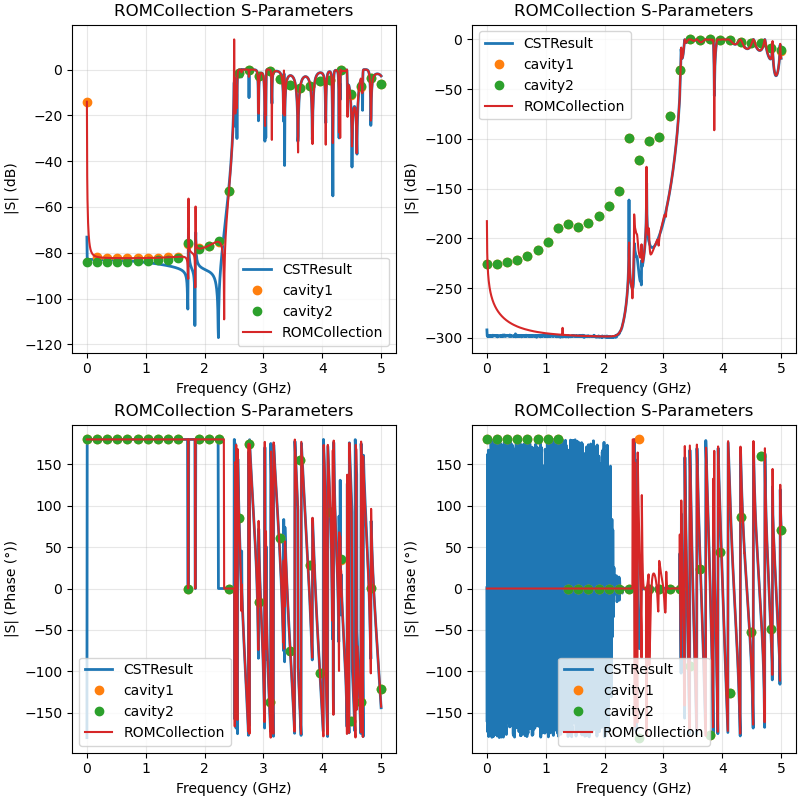

In [5]:
from analytical.cst_result import CSTResult
import matplotlib.pyplot as plt
# compare fom, rom, CST and analytical solution
# get cst solution

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\tesla1cell_double')
# plot comparison
which = [['1(1)1(1)'], ['2(3)1(3)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_s(wh, ax=axs[idx+1], lw=2)
    proj.fds.foms.plot_s(wh, ax=axs[idx+1], marker='o', lw=0)
    roms.plot_s(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_s(wh, plot_type='phase', ax=axs[idx+3], lw=2)
    (proj.fds.
     foms.plot_s(wh, plot_type='phase', ax=axs[idx+3], marker='o', lw=0))
    roms.plot_s(wh, plot_type='phase', ax=axs[idx+3])
plt.show()

In [6]:
concat = proj.fds.foms.roms.concatenate()
roms_config = {
    'nportmodes': 3,
    'nsamples': 1001, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 5,
    'solver_type': 'direct', # <- changed to direct method, faster for smaller matrices
    'rerun': True
}
rom_result = concat.solve(config=roms_config) # solve reduced order model on more frequency samples

INFO:: 
Coupled unified system: 313 -> 310 DOFs
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla\fds\port_modes\port_modes.pkl
INFO:: FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla\fds
  Solve: 1.050s (1001 frequencies)
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla\fds\port_modes\port_modes.pkl
INFO:: FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla\fds


Loaded CST S-parameters from: tesla1cell_double
  Frequency range: 0.0010 - 5.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


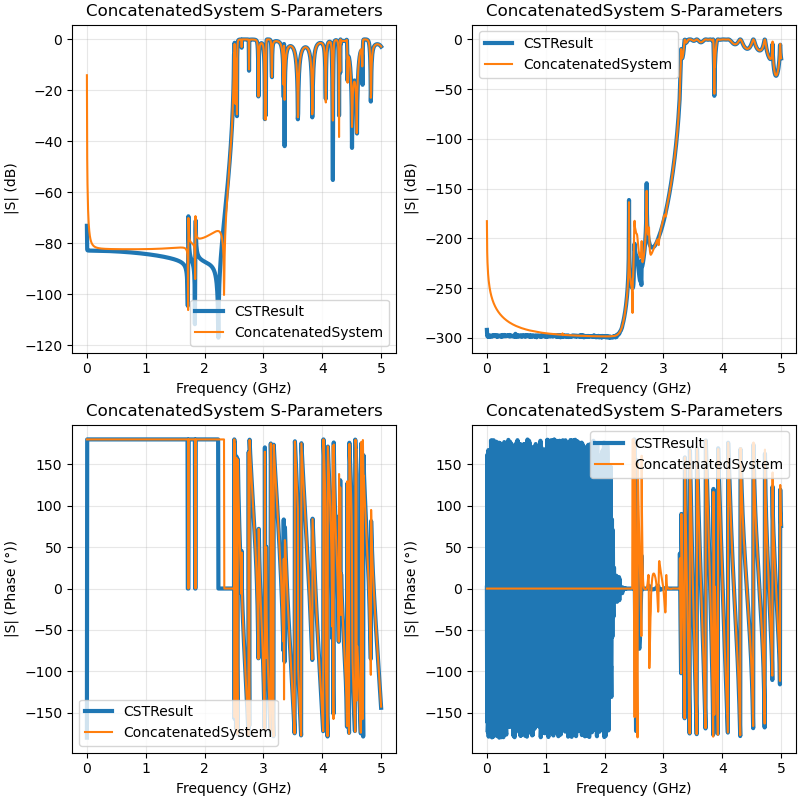

In [7]:
from analytical.cst_result import CSTResult
import matplotlib.pyplot as plt
# compare fom, rom, CST and analytical solution
# get cst solution

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\tesla1cell_double')
# plot comparison
which = [['1(1)1(1)'], ['2(3)1(3)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_s(wh, ax=axs[idx+1], lw=3)
    concat.plot_s(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_s(wh, plot_type='phase', ax=axs[idx+3], lw=3)
    concat.plot_s(wh, plot_type='phase', ax=axs[idx+3])
plt.show()

  Note: cavity1 residuals are zero. This is expected when using a direct solver (solver_type='direct').
  Note: cavity2 residuals are zero. This is expected when using a direct solver (solver_type='direct').


(<Figure size 600x600 with 2 Axes>,
 (<Axes: title={'center': 'Per-Domain Iterative Solver Convergence'}, xlabel='Frequency (GHz)', ylabel='GMRES Iterations'>,
  <Axes: ylabel='Relative Residual'>))

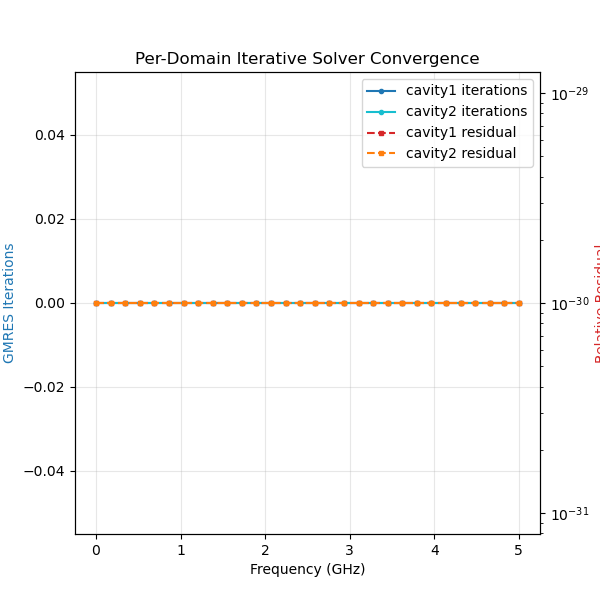

In [8]:
proj.fds.foms.plot_residual(figsize=(6, 6))